# Reading a Landscape with LGND Embeddings

LGND turns satellite imagery into **embeddings**: for every place on the map, a
compact list of numbers that captures what that place looks like from space. This
notebook shows those numbers are rich enough to **forecast**, **map crops**, and
**detect change** across a farming landscape, using nothing but the embeddings.

We work over row-crop country in California's Central Valley near Corcoran, where
fields green up and get harvested month to month and crops rotate year to year.
There are two parts:

**Part A: Forecasting.** Each location gets one embedding per month. Working forward
month by month, we predict a location's *next* embedding from its recent history,
check it against what actually happened, and then turn a predicted embedding back
into real imagery.

**Part B: Reading the land.** The embeddings also capture *what is growing*, so we
(1) build a **crop map** by classifying each field's growing-season embedding, and
(2) **detect change**: the gap between two years' embeddings flags which fields
switched crops, checked against the USDA Cropland Data Layer (CDL).

### How to run this

**Nothing to install or sign up for.** The notebook ships with a small prebuilt
dataset (the `lgnd_cache/` folder), so you can run every cell top to bottom and
watch it work. On Google Colab, click the "Open in Colab" badge in the README and
the first cell sets everything up for you.

**Want to see the API in action?** Flip `FETCH_EMBEDDINGS_FROM_API = True` in the
config cell and add your LGND API key. The forecasting section then pulls its
embeddings straight from the LGND API instead of the cache, so you can see exactly
how that works. Everything else keeps using the bundled dataset.

In [1]:
# Setup that works both locally and on Google Colab.
# On Google Colab, this installs the few packages Colab does not ship with and
# downloads the demo's data folder from the public LGND developer_resources repo,
# then works from there. Running locally it does nothing, since you already have
# the files next to the notebook. (Pure Python, no notebook magics, so it stays
# portable.)
import sys
import os
import subprocess
import pathlib

if "google.colab" in sys.modules and not pathlib.Path("lgnd_cache").exists():
    subprocess.run("pip install -q numpy pandas scikit-learn matplotlib pyarrow requests",
                   shell=True, check=True)
    subprocess.run("git clone --depth 1 "
                   "https://github.com/EarthLegend/developer_resources.git /content/lgnd_demo",
                   shell=True, check=True)
    os.chdir("/content/lgnd_demo/demo/Research-Tier-Demo-Notebook")
    print("Colab setup complete. Working folder:", os.getcwd())

## 1. Configuration

The area of interest is a ~15 km x 17 km rectangle of row-crop country near
Corcoran, California. By default everything is read from the bundled `lgnd_cache/`
folder, so no account or credentials are needed.

The one switch that matters is **`FETCH_EMBEDDINGS_FROM_API`**. Leave it `False` to
run entirely from the cache. Set it to `True` (and provide an LGND API key) to have
Part A pull its embeddings live from the LGND API instead.

In [2]:
import os
import json
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch

# Area of interest: rectangle around Corcoran, CA (lon/lat, WGS84).
LON_MIN, LON_MAX = -119.72, -119.55
LAT_MIN, LAT_MAX = 36.00, 36.15
CDL_YEARS = [2023, 2024, 2025]

# The one switch that matters.
# False: run entirely from the bundled cache (no key needed).
# True:  Part A fetches its embeddings live from the LGND API. Provide your key via a
#        Colab Secret named LGND_API_KEY, a local .env file, or the prompt that appears.
FETCH_EMBEDDINGS_FROM_API = False
COLLECTION_NAME = "central-valley-rotation-demo-v1"   # collection Part A reads in live mode

CACHE = pathlib.Path(os.environ.get("LGND_CACHE_DIR", "lgnd_cache"))
THUMBS = CACHE / "thumbs"
RNG = np.random.default_rng(42)


def cached(name):
    """Path to a required cache artifact, with a helpful error if it is missing."""
    p = CACHE / name
    assert p.exists(), (
        f"'{p}' not found. This notebook runs from a prebuilt cache folder. Ship "
        f"'lgnd_cache/' next to the notebook, build one with build_demo_cache_api.ipynb, "
        f"or set LGND_CACHE_DIR to a folder that has it."
    )
    return p


assert CACHE.exists(), (
    f"Cache folder '{CACHE}/' not found. Ship it alongside this notebook or build "
    "one with build_demo_cache_api.ipynb."
)
print(f"Reading cache: {CACHE}/")

Reading cache: lgnd_cache/


## 2. The dataset: a monthly embedding time series

A **collection** is "embeddings for *this geometry* over *this date range*,
computed by *this model*": here Clay v1.5 over Sentinel-2 surface reflectance,
with **monthly temporal deduplication** (one chip per grid cell per month). That
turns a large satellite archive into a clean, regular monthly time series.

We load the **inventory** (every chip, with its cell, month, and footprint,
chips at one location share a `cell_id`) and the **embeddings** (one vector per
chip).

23230 chips | 667 cells | 35 months (2023-01 .. 2025-11)
23230 embeddings loaded, dimension=256


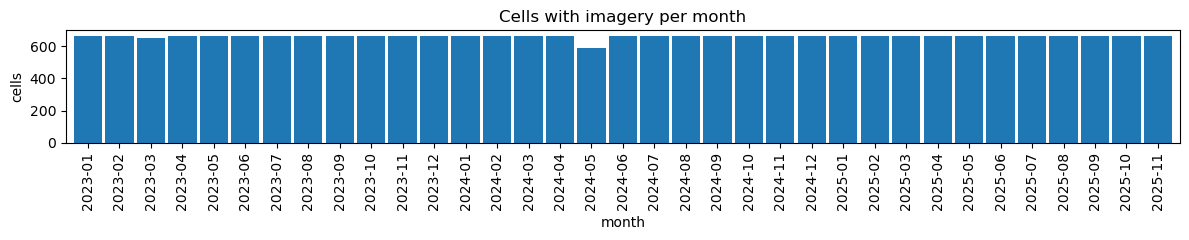

In [3]:
# The INVENTORY is the catalog: one row per chip, where a chip is one grid cell in
# one month, carrying its cell_id, month, lon/lat, and footprint polygon.
inv = pd.read_parquet(cached("inventory.parquet"))
MONTHS = sorted(inv["month"].unique())
print(f"{len(inv)} chips | {inv['cell_id'].nunique()} cells | "
      f"{len(MONTHS)} months ({MONTHS[0]} .. {MONTHS[-1]})")

# The EMBEDDINGS table pairs each chip_id with its vector (the model's numeric
# summary of that chip's imagery). Parquet stores the vector as a plain list, so we
# revive it as a float32 numpy array for fast math later.
emb = pd.read_parquet(cached("embeddings.parquet"))
emb["vector"] = emb["vector"].apply(lambda v: np.asarray(v, dtype=np.float32))
DIM = len(emb["vector"].iloc[0])
print(f"{len(emb)} embeddings loaded, dimension={DIM}")

# Lookups we reuse throughout: the vector for a chip, the chip at a (cell, month),
# and each cell's footprint. Building them once keeps the rest of the notebook fast.
vec_of = dict(zip(emb["chip_id"], emb["vector"]))
chip_at = {(r.cell_id, r.month): r.chip_id for r in inv.itertuples()}
geo = inv.groupby("cell_id")["geometry"].first()
LAT0 = inv["lat"].mean()   # mean latitude, used to keep the maps from looking stretched

# Coverage: how many cells have a chip in each month (gaps mean clouds or no pass).
coverage = inv.groupby("month")["cell_id"].nunique().reindex(MONTHS, fill_value=0)
fig, ax = plt.subplots(figsize=(12, 2.5))
coverage.plot.bar(ax=ax, width=0.9)
ax.set_title("Cells with imagery per month"); ax.set_ylabel("cells")
plt.tight_layout(); plt.show()


# Small shared helpers used across the notebook.
def poly_of(cell_id):
    """Footprint ring of a cell as a list of (lon, lat) tuples."""
    return [(x, y) for x, y in json.loads(geo[cell_id])["coordinates"][0]]


def set_geo_aspect(ax):
    ax.set_aspect(1 / np.cos(np.radians(LAT0)))   # correct lon/lat distortion


def thumbnail(chip_id):
    """Chip thumbnail loaded from the cache (the cache ships alongside this notebook)."""
    p = THUMBS / f"{chip_id}.jpg"
    if not p.exists():
        raise FileNotFoundError(f"{chip_id}.jpg not in cache")
    return plt.imread(p)


def show_chip_row(chip_ids, titles, suptitle=None, size=2.0):
    n = len(chip_ids)
    fig, axes = plt.subplots(1, n, figsize=(size * n, size + 0.5))
    axes = np.atleast_1d(axes)
    for ax, cid_, t in zip(axes, chip_ids, titles):
        try:
            ax.imshow(thumbnail(cid_))
        except Exception:
            ax.text(0.5, 0.5, "n/a", ha="center")
        ax.set_title(t, fontsize=8); ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=10)
    plt.tight_layout(); plt.show()

### Where we're working

A true-color Sentinel-2 view of the whole area of interest, ~15 x 17 km of
Central Valley farmland near Corcoran, CA: fields, canals, center-pivot circles,
and the town itself. This is the landscape the embeddings describe.

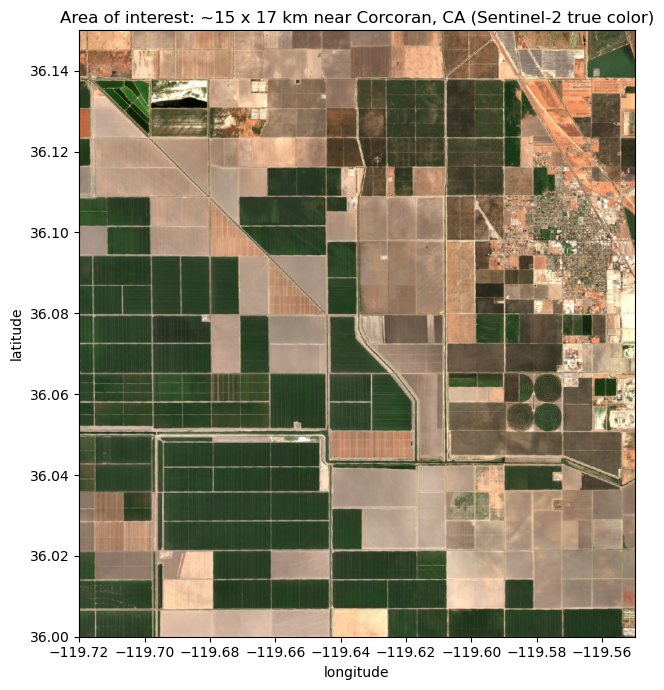

In [4]:
aoi_img = CACHE / "aoi.jpg"
if aoi_img.exists():
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(plt.imread(aoi_img), extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
    set_geo_aspect(ax)
    ax.set_title("Area of interest: ~15 x 17 km near Corcoran, CA (Sentinel-2 true color)")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    plt.tight_layout(); plt.show()
else:
    print("aoi.jpg not in cache, skipping the AOI overview (rebuild the cache to include it).")

### A location through time

Look at the raw material: one cell's monthly thumbnails
across a year. You can watch bare soil green up, peak, and get harvested. This
agriculture cycle is the structure the embeddings encode.

571 cells have complete 35-month coverage


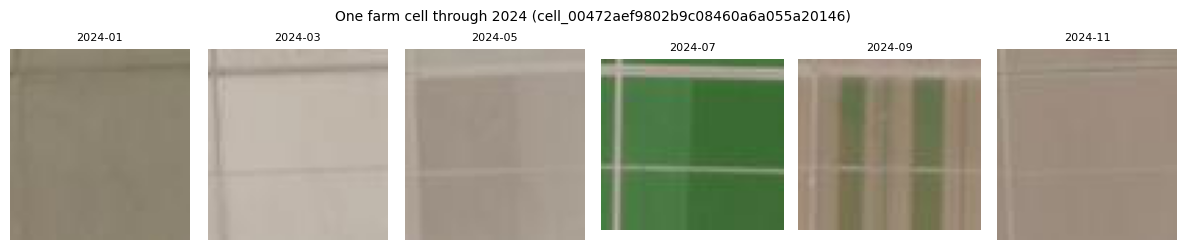

In [5]:
# Cells that have a chip in every month; these are the ones we can build a full
# time series for (and the ones Part A forecasts).
full_cells = (inv.groupby("cell_id")["month"].nunique()
              .loc[lambda s: s == len(MONTHS)].index.tolist())
assert full_cells, "No cell has complete monthly coverage; the cache date range is too narrow."
print(f"{len(full_cells)} cells have complete {len(MONTHS)}-month coverage")

# Walk one example cell through 2024, every other month (::2) so the strip stays
# readable. You can watch it go from bare soil to green canopy to harvested.
demo = inv[(inv["cell_id"] == full_cells[0]) & (inv["month"].str.startswith("2024"))]
demo = demo.sort_values("month").iloc[::2]
show_chip_row(demo["chip_id"].tolist(), demo["month"].tolist(),
              suptitle=f"One farm cell through 2024 ({full_cells[0]})")

## 3. Part A: Forecasting next month's embedding

Can we predict what a place will look like next month? For each location we line up
its embeddings into a monthly time series and predict the next month's embedding
from the three months before it, plus which calendar month we are aiming at so the
model can learn the seasons. One simple linear model (ridge regression) is shared
across every location.

We grade it the fair way, called **walk-forward**: for each of the last twelve
months we train using *only the months before it*, predict that month, and compare
to two simple baselines. **Persistence** guesses next month looks like this month;
**seasonal** guesses it looks like the same month a year ago. The score is **cosine
similarity** to the real embedding, a number where 1.0 means an exact match.
Averaging over a whole year of predictions (instead of one lucky or unlucky month)
keeps the comparison honest and shows *when* forecasting helps.

> **Live mode:** with `FETCH_EMBEDDINGS_FROM_API = True`, the embeddings below come
> from the LGND API (one `search-by-vector` call per month) instead of the cache,
> and the forecast runs on those. The rest of the notebook keeps using the cache.

### How the live fetch works (used only when the toggle is on)

This is the actual LGND API call. For each month we ask `search-by-vector` for the
chips in our area and request the embedding inline with `expand:["embedding"]`. The
query vector is arbitrary: when a month has fewer chips than `top_k`, the API returns
all of them regardless of ranking. We keep one embedding per field per month, which
is exactly the shape the cache provides, so Part A does not care where they came from.

In [6]:
def fetch_embeddings_from_api():
    """Fetch this area's monthly embeddings straight from the LGND API and return the
    same lookups the cache provides: {chip_id: vector}, {(cell, month): chip_id}, the
    list of months, and the fully-covered cells."""
    import requests
    import getpass

    # 1. Your API key: a Colab Secret named LGND_API_KEY, a local .env, or a prompt.
    key = os.environ.get("LGND_API_KEY")
    if not key:
        try:
            from google.colab import userdata
            key = userdata.get("LGND_API_KEY")
        except Exception:
            pass
    if not key:
        key = getpass.getpass("Enter your LGND API key (sk_...): ")
    base = "https://embeddings.api.lgnd.ai"
    headers = {"Authorization": f"Bearer {key}", "Content-Type": "application/json"}

    # 2. Find the collection over this area in your tenant, plus its search index.
    tenant = requests.get(base + "/v1/tenants", headers=headers, timeout=30).json()["data"][0]["id"]
    cols = requests.get(f"{base}/v1/tenants/{tenant}/collections", headers=headers, timeout=30).json()["data"]
    ready = [c for c in cols if c["name"] == COLLECTION_NAME and c["status"] == "READY"]
    assert ready, (
        f"No READY collection named '{COLLECTION_NAME}' in your tenant. Live mode needs a "
        "collection over this area; see the README to create one, or set "
        "FETCH_EMBEDDINGS_FROM_API = False to use the bundled dataset.")
    cid = ready[0]["id"]
    indexes = requests.get(f"{base}/v1/tenants/{tenant}/collections/{cid}/indexes",
                           headers=headers, timeout=30).json()["data"]
    index = next(i for i in indexes if i["status"] == "READY")
    dims = index.get("embedding_dims") or 256

    # 3. One search-by-vector call per month, with the embedding returned inline.
    aoi = {"type": "Polygon", "coordinates": [[
        [LON_MIN, LAT_MIN], [LON_MIN, LAT_MAX], [LON_MAX, LAT_MAX],
        [LON_MAX, LAT_MIN], [LON_MIN, LAT_MIN]]]}
    query = np.random.default_rng(0).standard_normal(dims); query /= np.linalg.norm(query)
    records = []
    for m in MONTHS:
        y, mo = int(m[:4]), int(m[5:7])
        ny, nmo = (y + 1, 1) if mo == 12 else (y, mo + 1)
        body = {"vector": query.tolist(), "top_k": 5000, "index_id": index["id"],
                "geometry": aoi, "expand": ["embedding"],
                "start_date": f"{m}-01", "end_date": f"{ny:04d}-{nmo:02d}-01"}
        data = requests.post(f"{base}/v1/tenants/{tenant}/collections/{cid}/search-by-vector",
                             headers=headers, json=body, timeout=180).json().get("data", [])
        records += [d for d in data if d.get("embedding") is not None]
        print(f"  {m}: {len(data)} chips")

    # 4. Reshape into the same lookups the cache gives us (one chip per cell per month).
    df = (pd.DataFrame([{"chip_id": d["chip_id"], "cell_id": d["cell_id"],
                         "month": d["datetime"][:7], "datetime": d["datetime"],
                         "vector": np.asarray(d["embedding"], dtype=np.float32)} for d in records])
          .sort_values("datetime").drop_duplicates(["cell_id", "month"], keep="last"))
    fc_vec = dict(zip(df["chip_id"], df["vector"]))
    fc_chip = {(r.cell_id, r.month): r.chip_id for r in df.itertuples()}
    fc_months = sorted(df["month"].unique())
    fc_cells = (df.groupby("cell_id")["month"].nunique()
                .loc[lambda s: s == len(fc_months)].index.tolist())
    print(f"fetched {len(df)} monthly embeddings across {len(fc_months)} months")
    return fc_vec, fc_chip, fc_months, fc_cells

Part A embeddings: loaded from the cache

         ridge  persistence  seasonal
month                                
2024-12  0.877        0.838     0.804
2025-01  0.887        0.884     0.787
2025-02  0.720        0.714     0.667
2025-03  0.880        0.697     0.841
2025-04  0.856        0.891     0.858
2025-05  0.896        0.872     0.865
2025-06  0.921        0.919     0.852
2025-07  0.920        0.895     0.850
2025-08  0.931        0.912     0.850
2025-09  0.927        0.901     0.854
2025-10  0.908        0.863     0.854
2025-11  0.936        0.955     0.876

Averaged over the last 12 months:  ridge 0.888  >  persistence 0.862  >  seasonal 0.830
the forecast beats persistence in 83% of months and helps 78% of fields on average


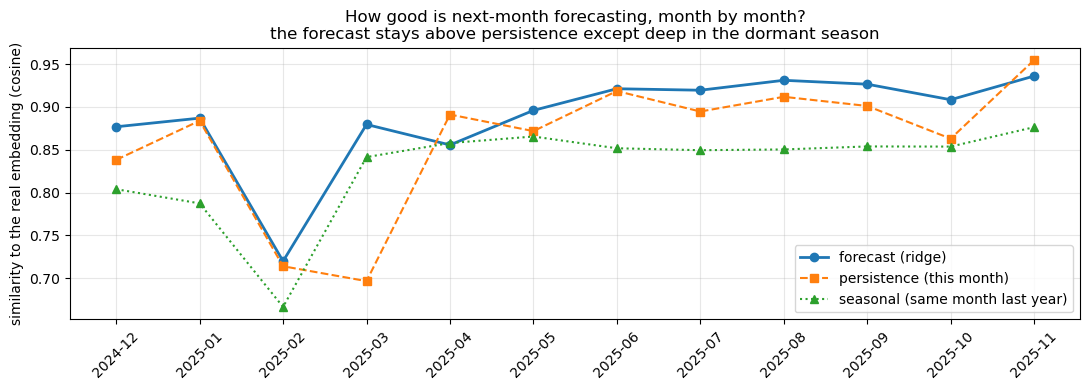

In [7]:
from sklearn.linear_model import Ridge

LAGS = 3   # how many months of history the model gets to see


def build_tensor(vec_lookup, chip_lookup, months, candidate_cells):
    """Stack each fully-covered cell's monthly embeddings into one array of shape
    (cells, months, dims). Entry [i, t] is cell i's embedding in month t."""
    cells_ = [c for c in candidate_cells if all((c, m) in chip_lookup for m in months)]
    E_ = np.stack([[vec_lookup[chip_lookup[(c, m)]] for m in months] for c in cells_])
    return E_, cells_


def cos(a, b):
    """Row-wise cosine similarity between two stacks of vectors (1.0 = identical)."""
    return np.sum(a * b, axis=1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + 1e-9)


def walk_forward(E, months, horizon=12):
    """Predict each of the last `horizon` months using only the months before it, and
    score the forecast against persistence (this month) and seasonal (same month last
    year). Returns a per-month score table, each cell's average gain over persistence,
    and the final month's prediction (reused by the decode section)."""
    N, n_months, dims = E.shape
    month_num = np.array([int(m[5:7]) - 1 for m in months])   # calendar month, 0..11

    def make_xy(targets):
        # features = the 3 previous months stacked + a flag for the target calendar
        # month (so the model can learn that, say, Julys tend to look alike).
        X, Y = [], []
        for t in targets:
            history = E[:, t - LAGS:t, :].reshape(N, LAGS * dims)
            season = np.zeros((N, 12)); season[:, month_num[t]] = 1.0
            X.append(np.hstack([history, season])); Y.append(E[:, t, :])
        return np.vstack(X), np.vstack(Y)

    rows, cell_gain = [], np.zeros(N)
    pred_final = persist_final = None
    for t in range(n_months - horizon, n_months):
        model = Ridge(alpha=10.0).fit(*make_xy(range(LAGS, t)))   # train on the past only
        actual = E[:, t, :]
        predicted = model.predict(make_xy([t])[0])
        ridge_s = cos(predicted, actual)
        persist_s = cos(E[:, t - 1, :], actual)
        season_s = cos(E[:, t - 12, :], actual) if t >= 12 else np.full(N, np.nan)
        rows.append({"month": months[t], "ridge": ridge_s.mean(),
                     "persistence": persist_s.mean(), "seasonal": np.nanmean(season_s)})
        cell_gain += ridge_s - persist_s
        if t == n_months - 1:                                    # final origin, reused below
            pred_final, persist_final = predicted, persist_s
    return pd.DataFrame(rows).set_index("month"), cell_gain / horizon, pred_final, persist_final


# The cache forecast always runs: it is what Part A shows unless you switch on the live
# API, and the decode section further down reuses its final-month prediction (so the
# retrieved images always line up with the bundled dataset).
E_cache, cells_cache = build_tensor(vec_of, chip_at, MONTHS, full_cells)
wf_cache, gain_cache, pred_final, persist_final = walk_forward(E_cache, MONTHS)

if FETCH_EMBEDDINGS_FROM_API:
    # Fetch the same kind of embeddings live from the LGND API and forecast on those.
    fc_vec, fc_chip, fc_months, fc_cells = fetch_embeddings_from_api()
    E_show, cells_show = build_tensor(fc_vec, fc_chip, fc_months, fc_cells)
    wf, gain, _, _ = walk_forward(E_show, fc_months)
    print("Part A embeddings: fetched live from the LGND API\n")
else:
    wf, gain, cells_show = wf_cache, gain_cache, cells_cache
    print("Part A embeddings: loaded from the cache\n")

# One row per predicted month, then the headline averages across the whole year.
print(wf.round(3))
print(f"\nAveraged over the last {len(wf)} months:  ridge {wf['ridge'].mean():.3f}  >  "
      f"persistence {wf['persistence'].mean():.3f}  >  seasonal {wf['seasonal'].mean():.3f}")
print(f"the forecast beats persistence in {(wf['ridge'] > wf['persistence']).mean() * 100:.0f}% "
      f"of months and helps {(gain > 0).mean() * 100:.0f}% of fields on average")

# Plot the three curves month by month. The forecast sits above persistence for most
# of the year; the one stretch where "nothing changes" wins is the dormant late fall.
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wf.index, wf["ridge"], "o-", lw=2, label="forecast (ridge)")
ax.plot(wf.index, wf["persistence"], "s--", label="persistence (this month)")
ax.plot(wf.index, wf["seasonal"], "^:", label="seasonal (same month last year)")
ax.set_ylabel("similarity to the real embedding (cosine)")
ax.set_title("How good is next-month forecasting, month by month?\n"
             "the forecast stays above persistence except deep in the dormant season")
ax.legend(); ax.tick_params(axis="x", rotation=45); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Where does forecasting help most?

Persistence is unbeatable for places that never change (orchards, roads). The
model's edge concentrates in *dynamic* row-crop fields. Each cell is drawn at its
true footprint and colored by the model's **mean** improvement over persistence
across the walk-forward months.

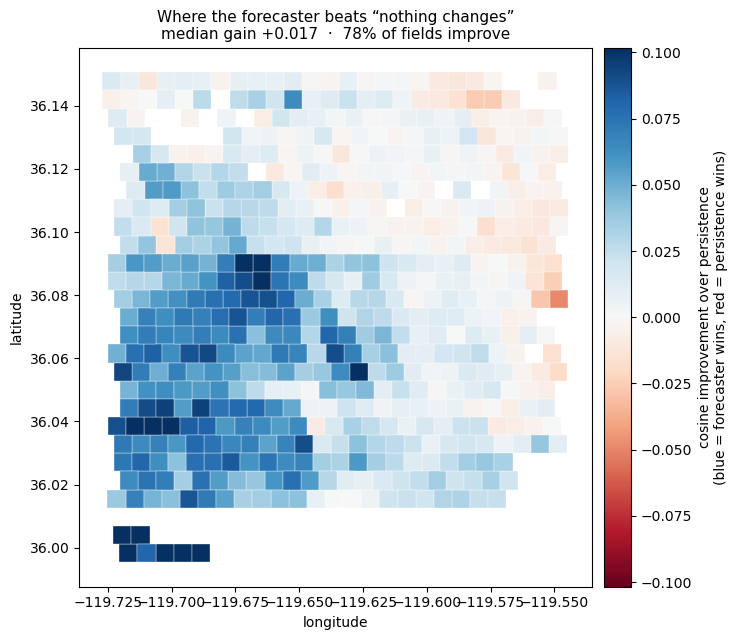

In [8]:
# Paint each field by how much the forecast beat persistence, averaged over the
# walk-forward year. Blue means the model helped; red means persistence was better.
# (Cached mode covers every field; live mode only draws fields we have a footprint for.)
plot_cells = [c for c in cells_show if c in geo.index]
improve = pd.Series(gain, index=cells_show).loc[plot_cells]
vals = improve.values
M = max(np.quantile(np.abs(vals), 0.98), 1e-3)   # symmetric color range, ignoring outliers

fig, ax = plt.subplots(figsize=(7.5, 6.5))
pc = PolyCollection([poly_of(c) for c in improve.index], array=vals, cmap="RdBu",
                    norm=TwoSlopeNorm(vmin=-M, vcenter=0.0, vmax=M),
                    edgecolors="white", linewidths=0.25)
ax.add_collection(pc); ax.autoscale_view(); set_geo_aspect(ax)
cb = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.02)
cb.set_label("cosine improvement over persistence\n(blue = forecaster wins, red = persistence wins)")
ax.set_title("Where the forecaster beats “nothing changes”\n"
             f"median gain {np.median(vals):+.3f}  ·  {(vals > 0).mean() * 100:.0f}% of fields improve",
             fontsize=11)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.tight_layout(); plt.show()

## 4. Decoding a prediction into imagery

A predicted embedding is just numbers. Those numbers can be used to retrieve the real chips whose
embeddings sit closest to it, restricted to the held-out month. If the forecast
is good, the retrieved imagery looks like what the field actually became. This
is the clearest sign the embedding space is semantically organized: you can
navigate it with a vector you invented. (Here the lookup is a local
nearest-neighbor search over the cached vectors.)

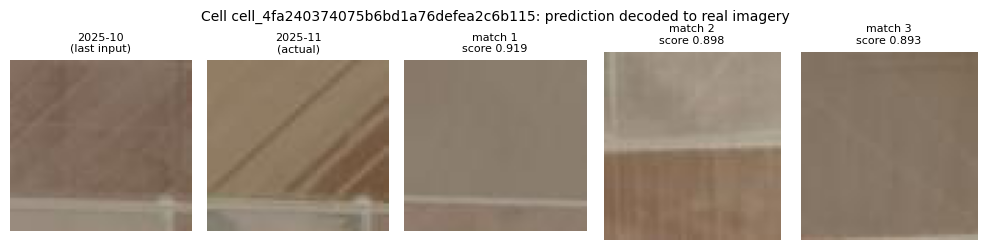

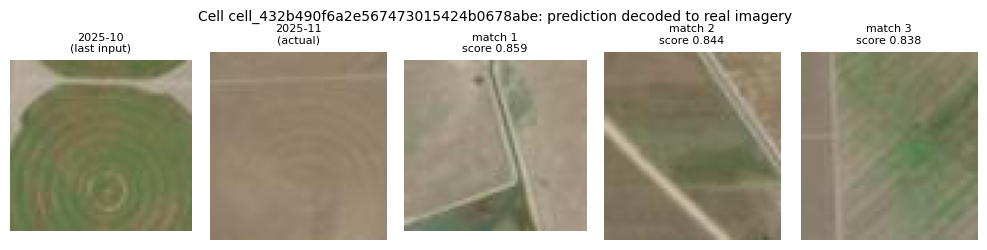

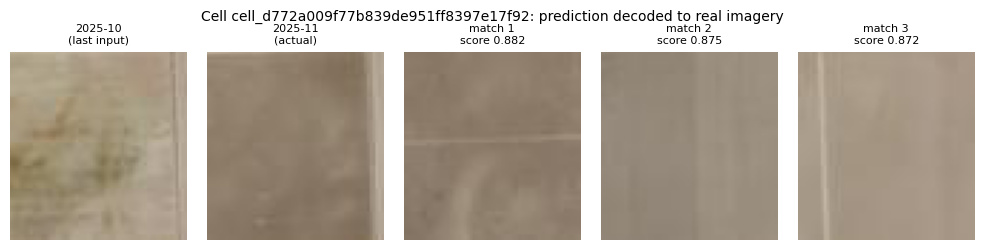

In [9]:
# Candidate pool: every real chip from the final (held-out) month. "Decoding" a
# predicted vector just means finding the real chips whose embeddings are closest to
# it (cosine nearest-neighbors), the same idea as search-by-vector but run locally.
held_out = MONTHS[-1]
cand_ids = [c for c in inv.loc[inv["month"] == held_out, "chip_id"] if c in vec_of]
cand_mat = np.stack([vec_of[c] for c in cand_ids])


def decode(vector, k=3):
    """Return the k held-out chips whose embeddings are most similar to `vector`."""
    sims = cand_mat @ vector / (np.linalg.norm(cand_mat, axis=1) * np.linalg.norm(vector) + 1e-9)
    top = np.argsort(-sims)[:k]
    return [(cand_ids[j], float(sims[j])) for j in top]


# The most dynamic cells (lowest persistence on the final step) are where a forecast
# is worth the most, so those are the ones we decode. Each row shows the last input
# month, the real held-out month, then the 3 chips the prediction retrieved. This uses
# the bundled dataset so the images always line up, even in live mode.
dynamic_cells = pd.Series(persist_final, index=cells_cache).nsmallest(3).index.tolist()
for c in dynamic_cells:
    i = cells_cache.index(c)
    hits = decode(pred_final[i])          # nearest real chips to this cell's predicted vector
    row_ids = [chip_at[(c, MONTHS[-2])], chip_at[(c, held_out)]] + [h[0] for h in hits]
    titles = [f"{MONTHS[-2]}\n(last input)", f"{held_out}\n(actual)"] + \
             [f"match {j+1}\nscore {s:.3f}" for j, (_, s) in enumerate(hits)]
    show_chip_row(row_ids, titles, suptitle=f"Cell {c}: prediction decoded to real imagery")

## 5. Part B: A crop map from embeddings

The embeddings don't just move through time; they encode *what is growing*. The
**USDA Cropland Data Layer (CDL)** gives a majority crop per field per year
(cached in `cdl_labels.parquet`). We build one feature per (field, year), the
**mean Apr–Sep growing-season embedding**, and train a classifier to name the
crop, then paint a crop map to see the result.

> Part B uses the bundled embeddings so they line up with the cached USDA labels.
> Pointing it at your own collection is easy: swap in your embeddings and the crop
> labels for your area, keeping the `cell_id` keys consistent between the two.

In [10]:
CDL_CODES = {
    1: "Corn", 2: "Cotton", 3: "Rice", 4: "Sorghum", 6: "Sunflower",
    21: "Barley", 22: "Durum Wheat", 23: "Spring Wheat", 24: "Winter Wheat",
    28: "Oats", 33: "Safflower", 36: "Alfalfa", 37: "Other Hay", 42: "Dry Beans",
    43: "Potatoes", 49: "Onions", 54: "Tomatoes", 61: "Fallow/Idle",
    66: "Cherries", 67: "Peaches", 69: "Grapes", 71: "Other Tree Crops",
    72: "Citrus", 75: "Almonds", 76: "Walnuts", 111: "Open Water",
    121: "Developed/Open", 122: "Developed/Low", 123: "Developed/Med",
    124: "Developed/High", 131: "Barren", 152: "Shrubland", 176: "Grass/Pasture",
    190: "Woody Wetlands", 195: "Herb. Wetlands", 204: "Pistachios",
    205: "Triticale", 206: "Carrots", 208: "Garlic", 209: "Cantaloupes",
    211: "Olives", 212: "Oranges", 217: "Pomegranates", 220: "Plums",
    221: "Strawberries", 225: "Wheat/Corn Dbl", 227: "Lettuce",
}
# CDL labels land cover with integer codes; this maps the common ones to names.
name_of = lambda code: CDL_CODES.get(int(code), f"CDL {int(code)}")
NONAG = {111, 121, 122, 123, 124, 131, 190, 195}  # non-crop: water / developed / wetland

# labels[year][cell_id] = the majority CDL crop code for that field that year.
cdl = pd.read_parquet(cached("cdl_labels.parquet"))
labels = {}
for year, g in cdl.groupby("year"):
    labels[int(year)] = {row.cell_id: (int(row.code) if pd.notna(row.code) else None)
                         for row in g.itertuples()}


def season_feature(cell, year):
    """One feature vector per field-year: the mean of its Apr-Sep (growing season)
    embeddings. Returns None if fewer than 4 of those months are available."""
    vs = [vec_of[chip_at[(cell, f"{year}-{m:02d}")]]
          for m in range(4, 10) if (cell, f"{year}-{m:02d}") in chip_at]
    return np.mean(vs, axis=0) if len(vs) >= 4 else None


# Build the training table: one growing-season feature and its crop label per
# field-year, skipping non-crop classes and fields with too little coverage.
recs = []
for y in CDL_YEARS:
    for c in geo.index:
        code = labels[y].get(c)
        if code is None or code in NONAG:
            continue
        f = season_feature(c, y)
        if f is not None:
            recs.append((c, y, f, code))
freq = pd.Series([r[3] for r in recs]).value_counts()
keep = set(freq[freq >= 10].index)           # fold very rare crops into a single "Other" class
lab = lambda code: name_of(code) if code in keep else "Other"

X = np.stack([r[2] for r in recs])           # features: one embedding per field-year
Yc = np.array([lab(r[3]) for r in recs])     # labels: the crop name
yr = np.array([r[1] for r in recs])          # source year of each row (used for the split)
cell_arr = np.array([r[0] for r in recs])    # source field of each row (used for the map)
print(f"{len(recs)} field-years | classes: {sorted(set(Yc))}")

1824 field-years | classes: [np.str_('Alfalfa'), np.str_('Almonds'), np.str_('CDL 228'), np.str_('Corn'), np.str_('Cotton'), np.str_('Fallow/Idle'), np.str_('Grapes'), np.str_('Grass/Pasture'), np.str_('Other'), np.str_('Pistachios'), np.str_('Safflower'), np.str_('Tomatoes'), np.str_('Triticale'), np.str_('Winter Wheat')]


Crop classification from a single season's embedding:
  nowcast (train 2023-24 -> test 2025): accuracy 0.667 | macro-F1 0.408
  5-fold cross-validation accuracy:     0.778   (14 classes)


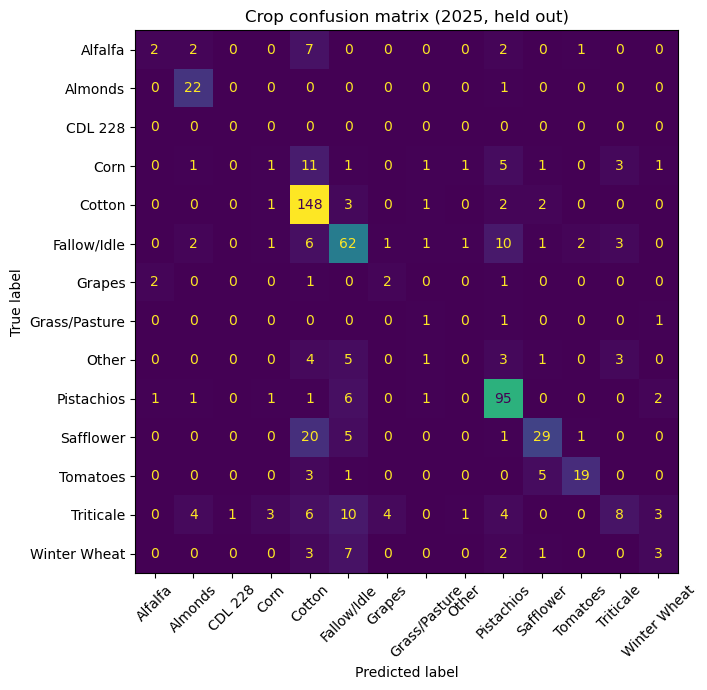

In [11]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

# Two ways to score the classifier:
#   nowcast: train on 2023+2024 and test on the held-out 2025 year (an honest,
#            out-of-time split, the way you would actually use this).
#   5-fold CV: shuffle all field-years into 5 folds for a second read on accuracy.
# NOTE: this cell trains a few gradient-boosted models, so give it a moment. :)
tr, te = yr < 2025, yr == 2025
clf = HistGradientBoostingClassifier(max_iter=300, random_state=0).fit(X[tr], Yc[tr])
pred_te = clf.predict(X[te])
acc = accuracy_score(Yc[te], pred_te)
f1 = f1_score(Yc[te], pred_te, average="macro", zero_division=0)
cv = cross_val_score(HistGradientBoostingClassifier(max_iter=300, random_state=0), X, Yc,
                     cv=StratifiedKFold(5, shuffle=True, random_state=0)).mean()
print(f"Crop classification from a single season's embedding:")
print(f"  nowcast (train 2023-24 -> test 2025): accuracy {acc:.3f} | macro-F1 {f1:.3f}")
print(f"  5-fold cross-validation accuracy:     {cv:.3f}   ({len(set(Yc))} classes)")

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(Yc[te], pred_te, ax=ax, xticks_rotation=45,
                                        colorbar=False, values_format="d")
ax.set_title("Crop confusion matrix (2025, held out)")
plt.tight_layout(); plt.show()

### The crop map: predicted vs. ground truth

The real payoff is spatial. Below, every 2025 field is painted by its predicted
crop (left) and by the CDL ground truth (right). Where the two panels agree, the
embedding read the land correctly from just imagery and no other inputs.

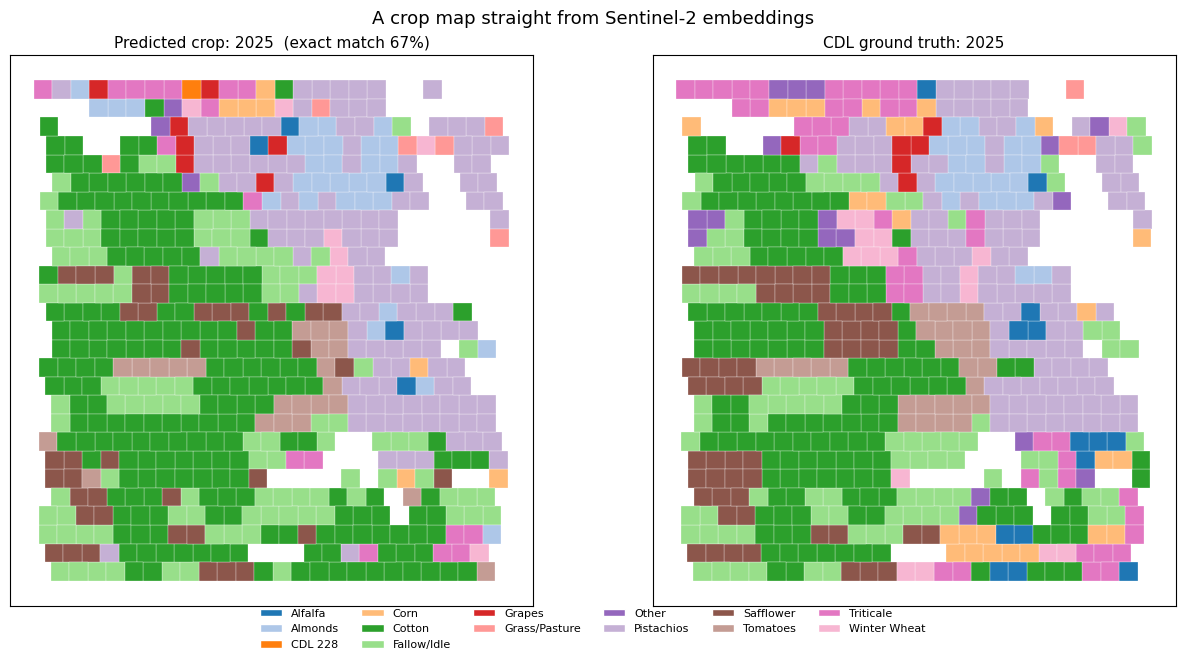

In [12]:
# Give each crop class a fixed color, then paint the 2025 fields twice: the model's
# prediction (left) next to the CDL ground truth (right). Where the colors match, the
# classifier read the field correctly.
classes = sorted(set(Yc))
palette = plt.cm.tab20(np.linspace(0, 1, 20))
class_color = {cl: palette[i % 20] for i, cl in enumerate(classes)}
te_cells = cell_arr[te]

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, vals, title in [(axes[0], pred_te, f"Predicted crop: 2025  (exact match {acc:.0%})"),
                        (axes[1], Yc[te], "CDL ground truth: 2025")]:
    pc = PolyCollection([poly_of(c) for c in te_cells],
                        facecolors=[class_color[v] for v in vals],
                        edgecolors="white", linewidths=0.2)
    ax.add_collection(pc); ax.autoscale_view(); set_geo_aspect(ax)
    ax.set_title(title, fontsize=11); ax.set_xticks([]); ax.set_yticks([])
handles = [Patch(facecolor=class_color[cl], edgecolor="white", label=cl) for cl in classes]
fig.legend(handles=handles, loc="lower center", ncol=min(len(classes), 6),
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("A crop map straight from Sentinel-2 embeddings", fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

### Sanity check: are the embeddings doing the work?

Shuffle the feature-to-label pairing and refit. If accuracy collapses toward the
majority-class rate, the skill really comes from the imagery, not leakage.

In [13]:
# Control: scramble which label goes with which feature, then refit and re-score.
# If the real model is genuinely reading the imagery (and not leaking), this shuffled
# version should collapse toward the majority-class rate.
perm = RNG.permutation(tr.sum())
clf_shuf = HistGradientBoostingClassifier(max_iter=300, random_state=0)
clf_shuf.fit(X[tr][perm], Yc[tr])
maj = pd.Series(Yc[tr]).value_counts(normalize=True).iloc[0]
print(f"shuffled-features accuracy: {accuracy_score(Yc[te], clf_shuf.predict(X[te])):.3f} | "
      f"majority-class rate: {maj:.3f} | real model: {acc:.3f}")

shuffled-features accuracy: 0.192 | majority-class rate: 0.350 | real model: 0.667


## 6. Part B: Change detection: which fields changed?

Because the embedding captures *what a field is*, the **distance between two years'
embeddings measures how much it changed**. This is automatic, label-free change
detection. We check it against the CDL: does a big embedding shift really line up
with a crop change? The score is **ROC-AUC**, a standard 0.5-to-1.0 measure where
0.5 is a coin flip and 1.0 is perfect. (Note the asymmetry: *detecting* a past change
is easy, but *predicting* next year's rotation is near-impossible, because next
year's crop is a farmer's economic decision, not something in this year's pixels.)

583 fields | 56% actually changed crop 2024->2025
embedding-distance ROC-AUC for 'did the crop change?': 0.847
(for contrast, PREDICTING next year's change from one year of imagery is ~0.51 = chance)


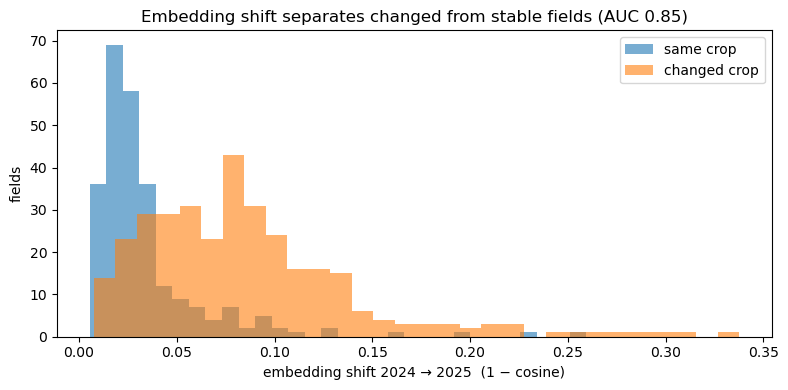

In [14]:
from sklearn.metrics import roc_auc_score

# For each field present in both years, measure how far its growing-season embedding
# moved from 2024 to 2025 (dist = 1 - cosine, so bigger means more change), and record
# whether the CDL crop label actually changed. No labels are used to compute the shift;
# the CDL is only the answer key we grade against.
rows = []
for c in geo.index:
    a, b = labels[2024].get(c), labels[2025].get(c)
    if a is None or b is None or a in NONAG or b in NONAG:
        continue
    fa, fb = season_feature(c, 2024), season_feature(c, 2025)
    if fa is None or fb is None:
        continue
    dist = 1.0 - float(fa @ fb / (np.linalg.norm(fa) * np.linalg.norm(fb) + 1e-9))
    rows.append((c, dist, int(a != b), a, b))

# ROC-AUC asks: does a larger embedding shift reliably rank the changed fields above
# the unchanged ones? 0.5 is chance, 1.0 is perfect separation.
chg = pd.DataFrame(rows, columns=["cell_id", "dist", "changed", "code_2024", "code_2025"])
auc = roc_auc_score(chg["changed"], chg["dist"])
print(f"{len(chg)} fields | {chg['changed'].mean():.0%} actually changed crop 2024->2025")
print(f"embedding-distance ROC-AUC for 'did the crop change?': {auc:.3f}")
print("(for contrast, PREDICTING next year's change from one year of imagery is ~0.51 = chance)")

# distributions of embedding shift for changed vs unchanged fields
fig, ax = plt.subplots(figsize=(8, 4))
for k, nm2 in [(0, "same crop"), (1, "changed crop")]:
    ax.hist(chg.loc[chg["changed"] == k, "dist"], bins=30, alpha=0.6, label=nm2)
ax.set_xlabel("embedding shift 2024 → 2025  (1 − cosine)"); ax.set_ylabel("fields")
ax.legend(); ax.set_title(f"Embedding shift separates changed from stable fields (AUC {auc:.2f})")
plt.tight_layout(); plt.show()

### Change-intensity map

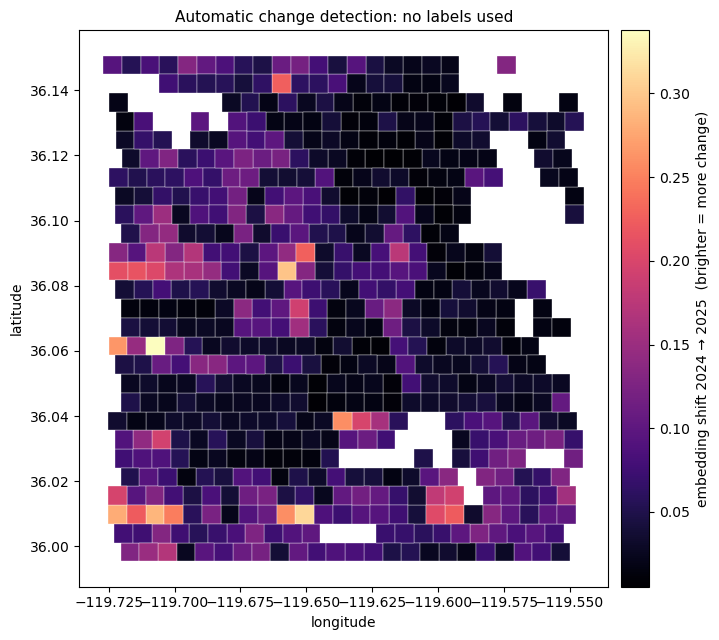

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
pc = PolyCollection([poly_of(c) for c in chg["cell_id"]], array=chg["dist"].values,
                    cmap="magma", edgecolors="white", linewidths=0.25)
ax.add_collection(pc); ax.autoscale_view(); set_geo_aspect(ax)
cb = fig.colorbar(pc, ax=ax, fraction=0.046, pad=0.02)
cb.set_label("embedding shift 2024 → 2025  (brighter = more change)")
ax.set_title("Automatic change detection: no labels used", fontsize=11)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.tight_layout(); plt.show()

### The biggest detected changes (before / after)

The fields with the largest embedding shift, pulled straight from the ranking
above, are real, visible crop transitions.

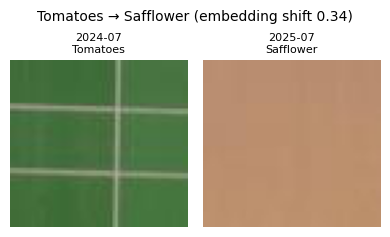

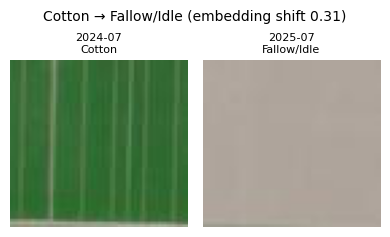

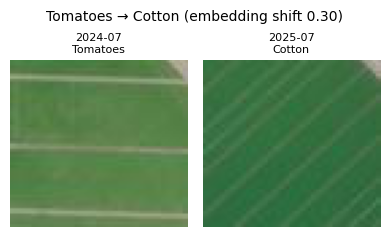

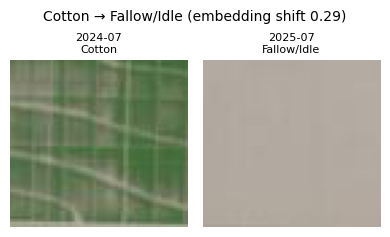

In [16]:
# Take the 4 fields with the biggest shift that also changed crop, and show their
# July chip from each year side by side. The titles read as the crop transition.
top = chg[chg["changed"] == 1].sort_values("dist", ascending=False).head(4)
for r in top.itertuples():
    ids, titles = [], []
    for yr_, code in [(2024, r.code_2024), (2025, r.code_2025)]:
        m = f"{yr_}-07"
        if (r.cell_id, m) in chip_at:
            ids.append(chip_at[(r.cell_id, m)]); titles.append(f"{m}\n{name_of(code)}")
    show_chip_row(ids, titles,
                  suptitle=f"{name_of(r.code_2024)} → {name_of(r.code_2025)} "
                           f"(embedding shift {r.dist:.2f})")

## 7. Wrap-up

**What we showed, using only Sentinel-2 embeddings:**

1. **Forecastable.** A plain ridge regression predicts next month's embedding and,
   evaluated walk-forward across a full year, beats both persistence and seasonal
   baselines, especially when the landscape is actually changing.
   We can also decode a predicted vector back into real imagery.
2. **Semantic.** A single growing-season embedding classifies a field's crop and
   paints a crop map that lines up with the USDA ground truth.
3. **Change-aware.** The distance between two years' embeddings detects which
   fields changed at **ROC-AUC ~0.85**, with no labels. Useful for monitoring
   or building datasets.

*Data credits: Sentinel-2 (ESA / Copernicus); Cropland Data Layer (USDA NASS);
embeddings by LGND (Clay v1.5).*